In [127]:
# Install dependencies

!pip install optuna -q

In [128]:
# Mount google drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [129]:
# Paths of directories

drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc"
code_data_path = f"{root_path}/code-data"

dataset_path = f"{code_data_path}/dataset"
current_path = f"{code_data_path}/training/2d_material"

In [130]:
# Global variables

SEED = 42


In [131]:
# Load original dataset

import pandas as pd

dataset = pd.read_pickle(f"{dataset_path}/dataset_2d_solvent_features_hsp_pubchem_bp.pkl")
dataset['molecular_weight'] = pd.to_numeric(dataset['molecular_weight'], errors='coerce')  # convert to numeric
dataset = dataset.fillna(dataset.mean(numeric_only=True))  # fill nan with mean

print(dataset.shape)
dataset.head()

(235, 35)


,c2db_id,normalized_value,gap,work_function,formation_energy,ehull,alphax_el,alphay_el,alphaz_el,plasmafrequency_x,...,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg
0,1BN-1,0.210000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,1,1,0,4,0,0,0,1,455.7,760.00
1,1BN-1,0.477404,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,1,1,1,4,0,0,0,1,370.3,760.00
2,1BN-1,0.546929,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,0,1,0,4,0,0,0,1,329.3,760.00
3,1BN-1,0.360000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,0,1,0,8,0,0,0,1,380.2,17.25
4,1BN-1,0.389386,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,0,1,0,6,0,0,0,1,438.2,760.00


In [132]:
# Dataset for machine learning

df = dataset.select_dtypes(include=['number'])  # remove non-numeric columns

print(df.shape)
df.head()

(235, 33)


,normalized_value,gap,work_function,formation_energy,ehull,alphax_el,alphay_el,alphaz_el,plasmafrequency_x,plasmafrequency_y,...,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg
0,0.210000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,1,1,0,4,0,0,0,1,455.7,760.00
1,0.477404,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,1,1,1,4,0,0,0,1,370.3,760.00
2,0.546929,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,0,1,0,4,0,0,0,1,329.3,760.00
3,0.360000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,0,1,0,8,0,0,0,1,380.2,17.25
4,0.389386,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,0,1,0,6,0,0,0,1,438.2,760.00


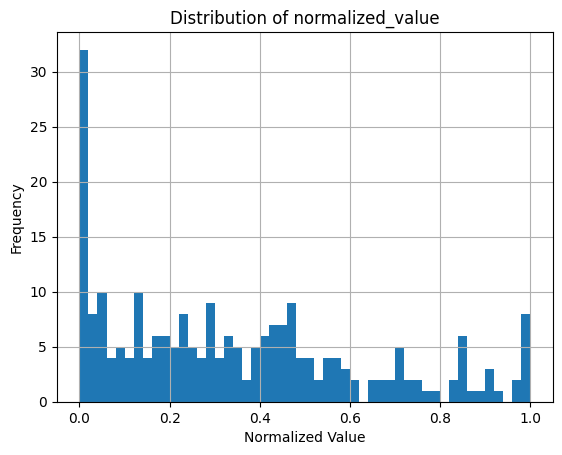

In [133]:
# Distribution of target values

import matplotlib.pyplot as plt

df["normalized_value"].hist(bins=50)
plt.xlabel("Normalized Value")
plt.ylabel("Frequency")
plt.title("Distribution of normalized_value")
plt.show()

In [134]:
# X, y datasets

X = df.drop(columns=["normalized_value"])
y = (df["normalized_value"] >= df["normalized_value"].mean()).astype(int)

y.value_counts()

,count
normalized_value,
0,133
1,102


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial f1 score: 0.8108
Best params: {'lambda': 9.92883164584266, 'alpha': 3.676046258694677, 'colsample_bytree': 0.5921698179663129, 'subsample': 0.6621467956498466, 'learning_rate': 0.11177687532360693, 'max_depth': 4, 'min_child_weight': 8}
Test ROC AUC: 0.8907
Best Threshold by Accuracy: 0.58, Accuracy: 0.8511
Best Threshold by F1: 0.58, F1: 0.8000


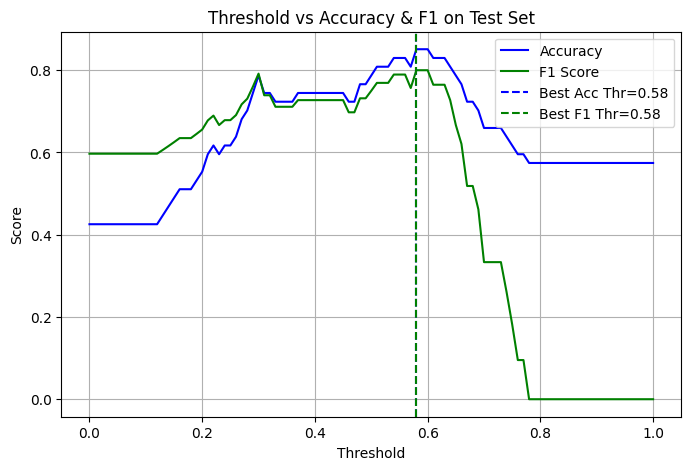

In [135]:
# Find best parameters and best target value threshold

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Split dataset train/val/test

from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval)

# Optuna objective function
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': SEED,
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0),
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'subsample': trial.suggest_float('subsample', 0.3, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
    }
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_val)

    return f1_score(y_val, y_pred)

# Tune parameters via Optuna
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best trial f1 score: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# Train the final model（train set + val set）
best_params = study.best_params

model_final = xgb.XGBClassifier(**best_params)
model_final.fit(X_trainval, y_trainval)

# Predict probability on test set
y_test_prob = model_final.predict_proba(X_test)[:, 1]

# Search target value threshold
thresholds = np.arange(0.0, 1.01, 0.01)
acc_list, f1_list = [], []

for thr in thresholds:
    y_test_pred = (y_test_prob >= thr).astype(int)
    acc_list.append(accuracy_score(y_test, y_test_pred))
    f1_list.append(f1_score(y_test, y_test_pred))

best_thr_acc = thresholds[np.argmax(acc_list)]
best_acc = max(acc_list)

best_thr_f1 = thresholds[np.argmax(f1_list)]
best_f1 = max(f1_list)

roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Test ROC AUC: {roc_auc:.4f}")
print(f"Best Threshold by Accuracy: {best_thr_acc:.2f}, Accuracy: {best_acc:.4f}")
print(f"Best Threshold by F1: {best_thr_f1:.2f}, F1: {best_f1:.4f}")

# Visuaize
plt.figure(figsize=(8, 5))
plt.plot(thresholds, acc_list, label='Accuracy', color='blue')
plt.plot(thresholds, f1_list, label='F1 Score', color='green')
plt.axvline(best_thr_acc, color='blue', linestyle='--', label=f'Best Acc Thr={best_thr_acc:.2f}')
plt.axvline(best_thr_f1, color='green', linestyle='--', label=f'Best F1 Thr={best_thr_f1:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Accuracy & F1 on Test Set')
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

           0       0.81      0.96      0.88        27
           1       0.93      0.70      0.80        20

    accuracy                           0.85        47
   macro avg       0.87      0.83      0.84        47
weighted avg       0.86      0.85      0.85        47

Accuracy: 0.8511, Precision: 0.9333, Recall: 0.7000, F1: 0.8000


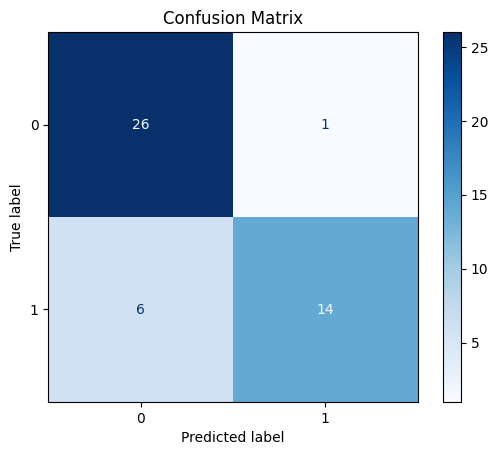

In [136]:
y_test_pred = (y_test_prob >= best_thr_f1).astype(int)

from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(classification_report(y_test, y_test_pred))

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

